In [1]:
import pandas as pd

In [2]:
df = pd.read_csv(r'G:\My Drive\Repository\WeekDays\ML_03PM_WD_Jul2026\movies_dataset.csv')

In [3]:
df.shape

(1500, 2)

In [4]:
df.isnull().sum()

Movie Name    0
Genres        0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Movie Name  1500 non-null   object
 1   Genres      1500 non-null   object
dtypes: object(2)
memory usage: 23.6+ KB


In [6]:
df.head(3)

,Movie Name,Genres
0,Broken Heart,"Drama, History, Comedy"
1,Fading Nights,"Romance, Biography, Action"
2,Beyond the Shattered Frontier,"Sport, Sci-Fi, Action, Horror"


In [16]:
df['Genres'] = df['Genres'].map( lambda val : val.replace('Sci-Fi','SciFi'))

In [17]:
from sklearn.feature_extraction.text import CountVectorizer

In [18]:
cv = CountVectorizer()

In [19]:
genre_matrix = cv.fit_transform(df['Genres'])

In [20]:
genre_matrix

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 6003 stored elements and shape (1500, 20)>

In [21]:
genre_matrix.toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 1, 0]], shape=(1500, 20))

In [22]:
genre_matrix.toarray()[0]

array([0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [23]:
cv.get_feature_names_out()

array(['action', 'adventure', 'animation', 'biography', 'comedy', 'crime',
       'documentary', 'drama', 'family', 'fantasy', 'history', 'horror',
       'musical', 'mystery', 'romance', 'scifi', 'sport', 'thriller',
       'war', 'western'], dtype=object)

In [25]:
from sklearn.metrics.pairwise import cosine_similarity

In [26]:
similarity = cosine_similarity(genre_matrix)

In [27]:
similarity

array([[1.        , 0.        , 0.        , ..., 0.51639778, 0.        ,
        0.28867513],
       [0.        , 1.        , 0.28867513, ..., 0.        , 0.33333333,
        0.        ],
       [0.        , 0.28867513, 1.        , ..., 0.2236068 , 0.57735027,
        0.25      ],
       ...,
       [0.51639778, 0.        , 0.2236068 , ..., 1.        , 0.25819889,
        0.4472136 ],
       [0.        , 0.33333333, 0.57735027, ..., 0.25819889, 1.        ,
        0.28867513],
       [0.28867513, 0.        , 0.25      , ..., 0.4472136 , 0.28867513,
        1.        ]], shape=(1500, 1500))

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

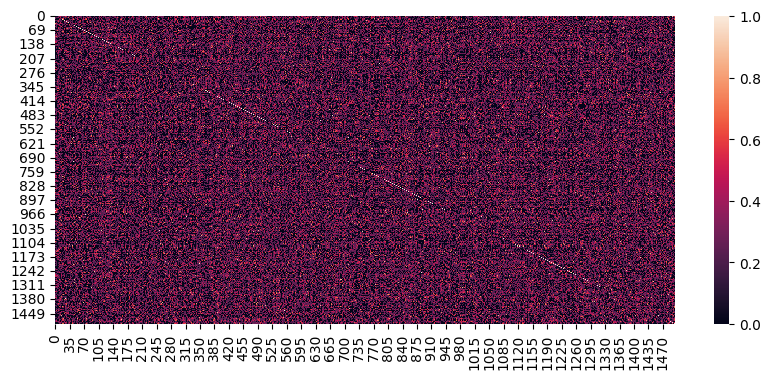

In [29]:
plt.figure( figsize=(10,4) )
sns.heatmap(similarity)
plt.show()

In [65]:
# recommendation method
def recommend(movie_name , n=5):
    matched = df[ df['Movie Name'].str.lower()==movie_name.lower() ]
    if matched.empty:
        return "Movie Not Found"
    movie_index = int(matched.index[0])
    movie_genre_matrix =  genre_matrix[movie_index].toarray()
    return similarity[66]

In [66]:
recommend('velvet sky')

array([0.25819889, 0.        , 0.        , ..., 0.4       , 0.        ,
       0.        ], shape=(1500,))